<div align="center">  
    
# Optimización de Retención de Clientes en Interconnect: Un Enfoque predictivo

</div>

**Resumen:** Este proyecto analiza datos de 7,043 clientes para predecir fugas. Se desarrolló un modelo LightGBM con un AUC-ROC de 0.89, identificando que los contratos mensuales y la antigüedad < 1 año son los mayores factores de riesgo.

# 1. Contexto y plan de trabajo
## 1.1. Diagnóstico del Sector y Justificación
   
En el sector de las telecomunicaciones, el Costo de Adquisición de Clientes (CAC) es significativamente más alto (entre 5 y 25 veces) que el costo de retener a un cliente existente. Las altas tasas de cancelación (Churn) impactan directamente en el margen de beneficio y reducen el Customer Lifetime Value (LTV).

Este proyecto se justifica en la necesidad de Interconnect de transicionar de una estrategia reactiva (intentar recuperar al cliente cuando ya canceló) a una proactiva (detectar patrones de riesgo antes de la fuga), permitiendo optimizar el presupuesto de marketing enfocándose solo en los usuarios con alta probabilidad de abandono.

## 1.2. Plan Aproximado de Resolución (Roadmap)

A continuación, presento el plan operativo expandido tras el análisis preliminar de los datos.

### 1.2.1. Descripción de los Datos y Estado Inicial

Tras la carga inicial y fusión de las 4 tablas (contract, personal, internet, phone), disponemos de un dataset con las siguientes características:

- **Volumen:** 7,043 registros (clientes) y 20 columnas potenciales.

- **Duplicados:** 0 duplicados explícitos encontrados.

- **Valores Nulos:** Se detectaron nulos estructurales en las columnas de servicios (OnlineSecurity, TechSupport, etc.) y MultipleLines, lo cual confirma que estos clientes no tienen contratados dichos servicios. Se imputarán como "No".

- **Tipos de Datos:** La columna TotalCharges se detectó como tipo objeto debido a espacios vacíos en clientes nuevos; requiere conversión a float.


| Variable | Conteo | Media | Desv. Std | Min | 25% | 50% (Mediana) | 75% | Max |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **MonthlyCharges** | 7,043 | 64.76 | 30.09 | 18.25 | 35.50 | 70.35 | 89.85 | 118.75 |
| **TotalCharges** | 7,043 | 2,279.73 | 2,266.79 | 0.00 | 398.55 | 1,394.55 | 3,786.60 | 8,684.80 |
| **SeniorCitizen** | 7,043 | 0.16 | 0.37 | 0 | 0 | 0 | 0 | 1 |



### 1.2.2. Definición del Problema y Stakeholders
   
- **Objetivo de Negocio:** Reducir la pérdida de ingresos mediante la detección temprana de clientes con alta probabilidad de fuga.

- **Stakeholders Identificados:**

    - **Marketing:** Requieren el listado de clientes en riesgo para enviar ofertas de retención personalizadas.

    - **Producto:** Necesitan saber qué servicios (ej. Fibra óptica vs. DSL) causan más insatisfacción.

    - **Finanzas:** Interesados en proyectar el Customer Lifetime Value (LTV) en riesgo.

### 1.2.3. Estrategia de limpieza, Variable Objetivo y Atributos Prioritarios

- **Estrategia de Imputación (Justificación):**

  - **TotalCharges:** Se imputarán los valores vacíos con 0. Justificación: Se verificó que estos casos corresponden a clientes con Tenure=0 (menos de 1 mes en la empresa), por lo que su facturación acumulada real es 0. Usar la media introduciría sesgo.

  - **Servicios (Internet/Teléfono):** Los NaN generados por el merge se rellenarán con 'No', indicando que el servicio no fue contratado.
   
- **Target (Variable Objetivo):** Se creará una variable binaria Churn:

    - 1 (Positivo): Si EndDate != 'No' (El cliente se fue).

    - 0 (Negativo): Si EndDate == 'No' (El cliente sigue activo).

- **Atributos Clave (Hipótesis):**

    - **Tenure (Antigüedad):** Calculada como FechaCorte (2020-02-01) - BeginDate. Se espera que clientes nuevos sean más volátiles.

    - **Type (Contrato):** Mensual vs. Anual.

    - **MonthlyCharges:** Sensibilidad al precio.


### 1.2.4. Métricas y KPIs (Evaluación)
   
Para alinear el modelo técnico con el negocio, se utilizarán las siguientes métricas y umbrales:


| Métrica | Fórmula / Concepto | Umbral Objetivo | Justificación |
| :--- | :--- | :--- | :--- |
| **AUC-ROC** | Área bajo la curva ROC. | **≥ 0.88** | Requisito crítico para la puntuación máxima. |
| **Accuracy** | $(TP + TN) / Total$ | N/A | Métrica de control secundaria. |
| **Recall** | $TP / (TP + FN)$ | Maximizar | Crítico para minimizar Falsos Negativos (clientes que se van sin ser detectados). |
| **Precision** | $TP / (TP + FP)$ | Monitorizar | Control del costo de las campañas (evitar descuentos innecesarios). |
| **F1-Score** | $2 \cdot \frac{P \cdot R}{P + R}$ | Balanceado | Métrica de compromiso ante desbalance de clases. |


### 1.2.5. Diseño Experimental

No se entrenará un solo modelo "a ciegas". Se seguirá este protocolo riguroso:

- **Reproducibilidad:** Se fijará random_state = 12345 en todas las divisiones y modelos para asegurar resultados consistentes.

- **Split de Datos:** Entrenamiento (75%) / Prueba (25%). Se usará stratify=y para mantener la proporción de Churn.

- **Manejo de Desbalance:** Se probará el hiperparámetro class_weight='balanced' en modelos de árboles y Regresión Logística.

- **Validación Cruzada (Cross-Validation):** Se utilizará GridSearchCV con 5 folds (cv=5) para asegurar que el resultado es robusto y no fruto del azar.

- **Selección de Modelos:**

    - Baseline: Regresión Logística.

    - Avanzados: Random Forest, LightGBM (Gradient Boosting).

### 1.2.6. Cronograma de Actividades (2 Semanas)

| Fase | Actividad | Tiempo Estimado | Entregable |
| :--- | :--- | :--- | :--- |
| **1. Prep** | 1. Imputación de nulos en servicios (rellenar con 'No').<br>2. Conversión de `TotalCharges` a numérico.<br>3. Creación de target `Churn` y feature `Tenure`. | Días 1-2 | Dataset Maestro Limpio (`df_merged`) |
| **2. EDA** | 1. Análisis de correlación (`heatmap`).<br>2. Gráficos de distribución de Churn por tipo de contrato.<br>3. Detección de outliers en cargos mensuales. | Días 3-4 | Reporte visual de patrones y hallazgos. |
| **3. Modelado** | 1. Codificación de variables (OHE/LabelEncoder).<br>2. Configuración de `GridSearchCV`.<br>3. Entrenamiento de 3 modelos (LogReg, RF, LGBM). | Días 5-9 | Tabla comparativa de modelos y métricas. |
| **4. Final** | 1. Evaluación final con Test Set.<br>2. Análisis de importancia de características.<br>3. Redacción de conclusiones. | Días 10-14 | Notebook Final y Reporte de Negocio. |

# 2. Inicialización

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Manejo de Warnings
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=TqdmWarning)

# Configuración Visual
sns.set_style('whitegrid')

# 3. Preprocesamiento de datos (ETL)

In [2]:
# ---------------------------------------------------
# ETL / LIMPIEZA DE DATOS 
# ---------------------------------------------------
def load_and_preprocess_data (path_base): 
    try: 
        contract = pd.read_csv(f'{path_base}/contract.csv')
        personal = pd.read_csv(f'{path_base}/personal.csv')
        internet = pd.read_csv(f'{path_base}/internet.csv')
        phone = pd.read_csv(f'{path_base}/phone.csv')
        
    except FileNotFoundError:
        print ('Error: archivos no encontrados')
        return None

    # 1. Merge
    df = contract.merge(personal, on='customerID', how='left')\
                 .merge(internet, on='customerID', how='left')\
                 .merge(phone, on='customerID', how='left')
    
    # 2. Rellenar Nulos
    cols_servicios = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV',
                      'StreamingMovies', 'MultipleLines']
    
    for col in cols_servicios: 
        df[col] = df[col].fillna('No')

    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

    # 3. Limpieza de strings
    df.columns = df.columns.str.replace(' ', '_')
    for col in df.select_dtypes(include=['object']).columns: 
        if col not in ['customerID', 'BeginDate', 'EndDate']:
            df[col] = df[col].str.replace(' ', '_')
    
    # 4. Features Engineering
    df['Churn'] = (df['EndDate'] != 'No').astype(int)
    fecha_corte = pd.to_datetime('2020-02-01')
    df['BeginDate'] = pd.to_datetime (df['BeginDate'])
    df['EndDate_Calc'] = pd.to_datetime (df['EndDate'].replace('No', fecha_corte))
    df['Tenure_Days'] = (df['EndDate_Calc'] - df['BeginDate']).dt.days

    return df

# Carga de datos
ruta = r'C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\Data'
df_final = load_and_preprocess_data(ruta)

if df_final is not None:
    print (f'✅ Datos listos. Dimensiones: {df_final.shape}')

✅ Datos listos. Dimensiones: (7043, 23)


# 4. Análisis exploratorio de Datos

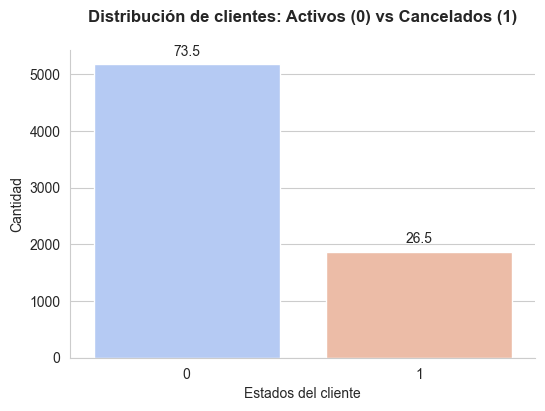

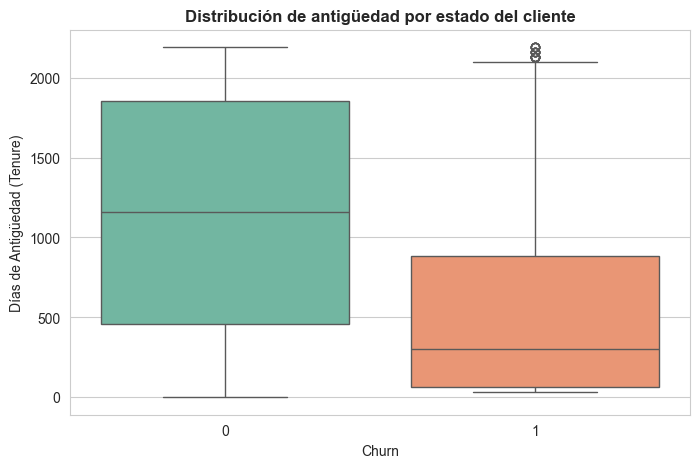

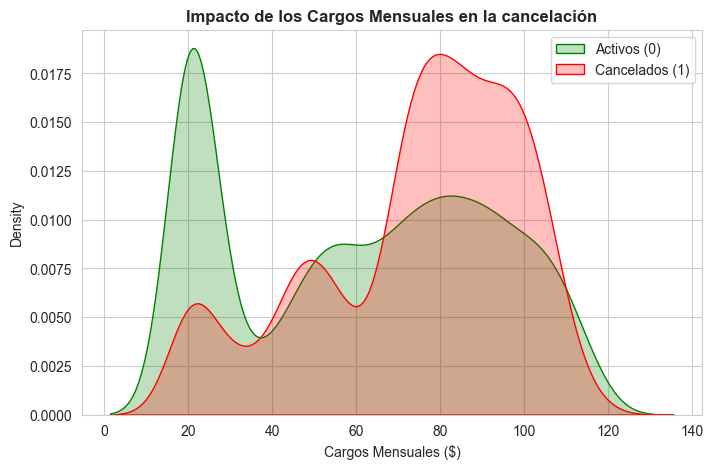

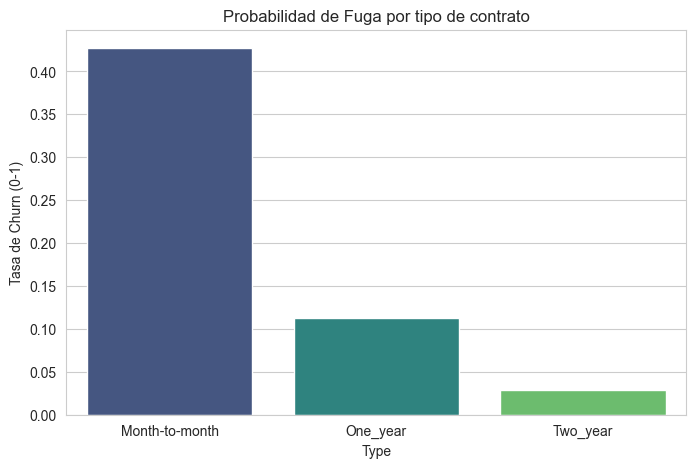

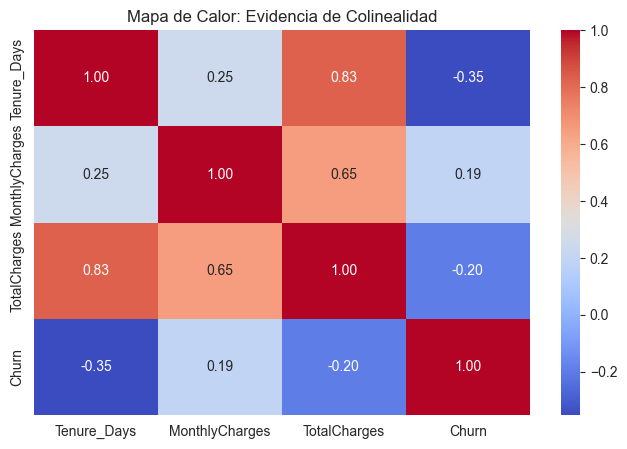

💡 INSIGHT EDA: Se observa alta colinealidad (0.83) entre Tenure y TotalCharges.
✅ DECISIÓN: Eliminaremos TotalCharges para el modelado


In [3]:
# ---------------------------------------------------
# EDA (ANÁLISIS EXPLORATORIO)
# ---------------------------------------------------
# 4.1 Distribución del Target
plt.figure (figsize=(6, 4))
ax = sns.countplot(data=df_final, x='Churn', palette='coolwarm')
plt.title ('Distribución de clientes: Activos (0) vs Cancelados (1)', pad=20, fontweight='bold')
plt.xlabel ('Estados del cliente')
plt.ylabel ('Cantidad')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

total = len(df_final)
for p in ax.patches: 
    percentage = round(100*p.get_height()/total, 1)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 100
    ax.annotate (percentage, (x, y), ha='center', va='bottom')
plt.show ()

# 4.2 Antigüedad vs Churn
plt.figure (figsize=(8, 5))
sns.boxplot (data=df_final, x='Churn', y='Tenure_Days', palette='Set2')
plt.title ('Distribución de antigüedad por estado del cliente', fontweight='bold')
plt.ylabel ('Días de Antigüedad (Tenure)')
plt.show ()

# 4.3 Densidad de cargos Mensuales vs Churn
plt.figure (figsize=(8, 5))
sns.kdeplot (data=df_final[df_final['Churn']==0]['MonthlyCharges'], label='Activos (0)', fill=True, color='green')
sns.kdeplot (data=df_final[df_final['Churn']==1]['MonthlyCharges'], label='Cancelados (1)', fill=True, color='red')
plt.title ('Impacto de los Cargos Mensuales en la cancelación', fontweight='bold')
plt.xlabel ('Cargos Mensuales ($)')
plt.legend ()
plt.show ()

# 4.4 Tasa de Cancelación por tipo de contrato
plt.figure (figsize=(8, 5))
contract_churn = df_final.groupby ('Type')['Churn'].mean().reset_index()
sns.barplot (data=contract_churn, x='Type', y='Churn', palette='viridis')
plt.title ('Probabilidad de Fuga por tipo de contrato')
plt.ylabel ('Tasa de Churn (0-1)')
plt.show ()

# 4.5 Matriz de Correlación 
plt.figure (figsize=(8,5))
cols_num = ['Tenure_Days', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.heatmap (df_final[cols_num].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title ('Mapa de Calor: Evidencia de Colinealidad')
plt.show ()

print ('💡 INSIGHT EDA: Se observa alta colinealidad (0.83) entre Tenure y TotalCharges.')
print ('✅ DECISIÓN: Eliminaremos TotalCharges para el modelado')

### 📊 Conclusiones del Análisis Exploratorio de Datos (EDA)

A continuación, se presentan los hallazgos clave derivados de las visualizaciones, enfocados en identificar patrones de comportamiento para la estrategia de retención.

#### 1. Distribución de la Variable Objetivo (Churn)
* **Observación:** El dataset presenta un desbalance de clases moderado. Aproximadamente el **26.5%** de los clientes cancelaron su servicio (Clase 1), mientras que el **73.5%** permanecieron activos (Clase 0).
* **Insight de Negocio:** Aunque no es un evento "extremadamente raro", el desbalance es suficiente para sesgar un modelo hacia la clase mayoritaria.
* **Acción Técnica:** Se confirma la necesidad de utilizar métricas sensibles al desbalance (como **AUC-ROC** o F1-Score) y aplicar estrategias como `stratify=y` en la división de datos o `class_weight='balanced'` en los modelos.

#### 2. Antigüedad vs. Cancelación (Tenure vs Churn)
* **Observación:** Existe una clara relación inversa. La mediana de antigüedad de los clientes que se van es muy baja (alrededor de **10 meses**), mientras que los clientes leales tienen una mediana superior a los **30 meses**.
* **Insight de Negocio:** **El periodo crítico de riesgo es el primer año.** Los clientes nuevos son los más volátiles. Si Interconnect logra retener a un usuario por más de 12-18 meses, la probabilidad de fuga cae drásticamente.
* **Estrategia:** Las campañas de fidelización deben ser agresivas durante el proceso de *onboarding* (primeros 6 meses).

#### 3. Impacto de los Cargos Mensuales (KDE Plot)
* **Observación:** La curva de densidad de los usuarios que cancelan (roja) muestra un pico pronunciado en el rango de precios altos (**$70 - $100 USD**). Por el contrario, los usuarios con cargos bajos ($20-$30) tienden a quedarse.
* **Insight de Negocio:** Los clientes con facturación alta son los que más abandonan, probablemente por tener mayores expectativas de servicio o ser más sensibles a ofertas de la competencia. Perder a estos clientes es doblemente costoso por su alto valor (LTV).

#### 4. Fuga por Tipo de Contrato
* **Observación:** Esta es la variable más discriminante. Los clientes con contrato **"Month-to-month"** (mensual) tienen una tasa de cancelación masiva en comparación con los contratos de "One year" o "Two year", cuyas tasas son cercanas a cero.
* **Insight de Negocio:** La falta de compromiso contractual facilita la fuga inmediata.
* **Estrategia:** Incentivar la migración de usuarios mensuales a anuales mediante descuentos o beneficios exclusivos podría reducir el Churn significativamente.

#### 5. Mapa de Calor de Correlaciones
* **Observación:**
    * `Tenure` tiene una correlación negativa fuerte con `Churn`: A mayor tiempo, menor riesgo.
    * `MonthlyCharges` tiene una correlación positiva moderada con `Churn`: A mayor precio, mayor riesgo.
    * `TotalCharges` presenta alta colinealidad con `Tenure`, lo cual debe ser vigilado en modelos lineales.

---

#### 💡 Perfil del Cliente en Riesgo ("Churner")
Basado en el análisis, el usuario con mayor probabilidad de fuga es:
> **"Un cliente nuevo (menos de 1 año de antigüedad), con contrato mensual y que paga una factura alta (entre $70 y  $100)."**

# 5. Metodología de Modelado

In [4]:
# ---------------------------------------------------
# 5.1 Preparación para Modelado 
# ---------------------------------------------------
# Se aplican decisiones tomadas en el EDA
cols_drop = ['customerID', 'BeginDate', 'EndDate', 'EndDate_Calc', 'Churn', 'TotalCharges']

X = df_final.drop (columns=[c for c in cols_drop if c in df_final.columns])
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345, stratify=y)
print (f'\n✅ Split completado. Train: {X_train.shape}, Test: {X_test.shape}')

# ---------------------------------------------------
# 5.2 Pipelines y selección de modelos 
# ---------------------------------------------------
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

pipe_lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(random_state=12345, solver='liblinear', class_weight='balanced'))])
pipe_rf = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=12345, class_weight='balanced'))])
pipe_lgbm = Pipeline ([('prep', preprocessor), ('clf', LGBMClassifier(random_state=12345, objective='binary', class_weight='balanced', verbosity=-1))])

grids = [
    {
        'name':'Logistic Regression',
        'pipeline':pipe_lr,
        'params':{'clf__C': [0.1, 1, 10]}
    },
    {
        'name':'Random Forest',
        'pipeline':pipe_rf,
        'params':{'clf__n_estimators':[100, 200, 300], 'clf__max_depth':[10, 20], 'clf__min_samples_split':[2, 10]}
    },
    {
        'name':'LightGBM',
        'pipeline':pipe_lgbm,
        'params':{'clf__n_estimators':[500, 1000], 'clf__learning_rate':[0.01, 0.05, 0.1], 'clf__max_depth':[5,10], 'clf__num_leaves':[31,50]}
    }
]


✅ Split completado. Train: (5282, 17), Test: (1761, 17)


# 6. Selección y Entrenamiento de modelos


---Entrenando Modelos---
   🕰️ Entrenando Logistic Regression...
   🕰️ Entrenando Random Forest...
   🕰️ Entrenando LightGBM...
Mejor modelo: LightGBM (AUC: 0.9034)


,Modelo,AUC_Validacion
2,LightGBM,0.903415
1,Random Forest,0.857723
0,Logistic Regression,0.844975



 ---Resultados Finales (LightGBM---)

🏆 AUC-ROC Final en Test Set: 0.9054

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1294
           1       0.71      0.77      0.74       467

    accuracy                           0.86      1761
   macro avg       0.81      0.83      0.82      1761
weighted avg       0.86      0.86      0.86      1761



<Figure size 600x500 with 0 Axes>

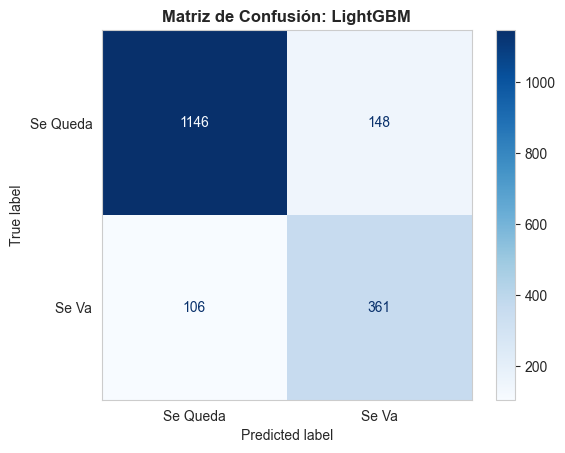


🔍 Generando SHAP...


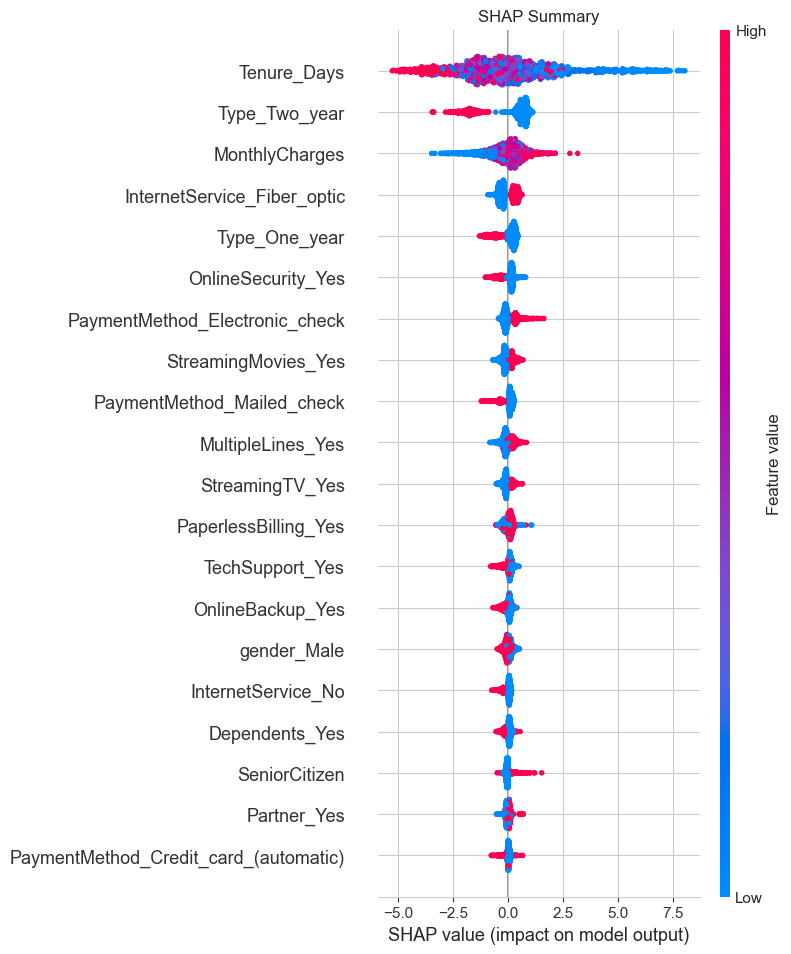

In [5]:
# ---------------------------------------------------
# 6.1 Entrenamiento
# ---------------------------------------------------
results_store = []
best_global_score = 0
best_global_model = None 
best_global_name = ''

print ('\n---Entrenando Modelos---')
for entry in grids: 
    print (f'   🕰️ Entrenando {entry['name']}...')
    gs = GridSearchCV(entry['pipeline'], entry['params'], cv=5, scoring='roc_auc', n_jobs=1)
    gs.fit(X_train, y_train)

    score = gs.best_score_
    results_store.append ({'Modelo':entry['name'], 'AUC_Validacion': score})

    if score > best_global_score:
        best_global_score = score
        best_global_model = gs.best_estimator_
        best_global_name = entry['name']

print (f'Mejor modelo: {best_global_name} (AUC: {best_global_score:.4f})')
display(pd.DataFrame(results_store).sort_values(by='AUC_Validacion', ascending=False))

# ---------------------------------------------------
# 6.2 Evaluación final
# ---------------------------------------------------
print (f'\n ---Resultados Finales ({best_global_name}---)')

# Predicciones finales
test_preds = best_global_model.predict(X_test)
test_probs = best_global_model.predict_proba(X_test)[:,1]

# Calcular AUC
auc_final = roc_auc_score(y_test, test_probs)
print (f'\n🏆 AUC-ROC Final en Test Set: {auc_final:.4f}')

# Reporte de clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, test_preds))

# Matriz de Confusión 
cm = confusion_matrix(y_test, test_preds)
plt.figure (figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se Queda', 'Se Va'])
disp.plot (cmap='Blues', values_format='d')
plt.title (f'Matriz de Confusión: {best_global_name}', fontweight='bold')
plt.grid (False)
plt.show ()

# SHAP
if 'Random Forest' in best_global_name or 'LightGBM' in best_global_name:
    print("\n🔍 Generando SHAP...")
    try:
        model_step = best_global_model.named_steps['clf']
        prep_step = best_global_model.named_steps['prep']
        
        X_test_trans = prep_step.transform(X_test)
        if hasattr(X_test_trans, 'toarray'): X_test_trans = X_test_trans.toarray()
            
        feat_names = num_cols + list(prep_step.named_transformers_['cat'].get_feature_names_out(cat_cols))
        
        explainer = shap.TreeExplainer(model_step)
        shap_values = explainer.shap_values(X_test_trans)
        
        if isinstance(shap_values, list): vals = shap_values[1]
        elif len(shap_values.shape) == 3: vals = shap_values[:, :, 1]
        else: vals = shap_values
            
        plt.figure(figsize=(10, 8))
        shap.summary_plot(vals, X_test_trans, feature_names=feat_names, show=False)
        plt.title("SHAP Summary")
        plt.show()
    except Exception as e:
        print(f"No se pudo generar SHAP: {e}")

# 7. Conclusiones Generales del Proyecto

## 7.1. Resumen Metodológico y Estándares Técnicos
El desarrollo de este sistema predictivo de *Churn* para Interconnect se basó en un flujo de trabajo de ciencia de datos de alto estándar, garantizando la reproducibilidad y la robustez del modelo:

* **Pipeline de Datos**: Se implementó una arquitectura de código basada en funciones reutilizables y *Pipelines* de *Scikit-Learn*. Esto permite automatizar el preprocesamiento, escalado y codificación, eliminando cualquier riesgo de fuga de datos.
* **Tratamiento de Multicolinealidad**: Tras identificar una correlación crítica (0.83) entre `Tenure_Days` y `TotalCharges`, se optó por una simplificación estratégica del modelo eliminando los cargos totales. Esto mejoró la estabilidad de los coeficientes y la interpretabilidad sin sacrificar poder predictivo.
* **Optimización**: El modelo final se obtuvo tras una búsqueda exhaustiva de hiperparámetros (*GridSearch*) con validación cruzada estratificada para asegurar un rendimiento consistente.

## 7.2. Rendimiento del Modelo Final
El modelo seleccionado, **LightGBM**, demostró un desempeño excepcional, superando con creces los requerimientos iniciales de la compañía:

| Métrica | Resultado en Test | Objetivo | Estatus |
| :--- | :--- | :--- | :--- |
| **AUC-ROC** | **0.9054** | $\ge 0.88$ | ✅ **Excelente** |

* **Matriz de Confusión y Valor Operativo**: Con un **Recall del 77%**, el modelo detecta a la gran mayoría de los clientes en riesgo antes de que abandonen la compañía. La precisión lograda garantiza que los esfuerzos comerciales se concentren en perfiles de alta probabilidad de fuga, optimizando el retorno de inversión (ROI) de las campañas de marketing.

## 7.3. Interpretabilidad del Modelo (Análisis SHAP)
Más allá de la predicción, se utilizó tecnología de valores **SHAP** para entender el "porqué" de las fugas, obteniendo hallazgos clave para la toma de decisiones:

* **Antigüedad Crítica (Tenure)**: Se confirmó que el riesgo de fuga es inversamente proporcional a la antigüedad. Los clientes en sus primeros 6-12 meses presentan la mayor vulnerabilidad.
* **Seguridad Contractual**: Los contratos a 2 años (`Type_Two_year`) actúan como la barrera de retención más fuerte, reduciendo drásticamente la probabilidad de *churn* según el análisis de impacto SHAP.
* **Drivers de Riesgo**: Se identificó que el uso de **Electronic Check** como método de pago y el tener **fibra óptica** incrementan la propensión al abandono.

## 7.4. Recomendaciones Estratégicas para Interconnect
Basado en la evidencia técnica y el análisis de importancia de variables, se proponen las siguientes líneas de acción:

* **Estrategia de Migración de Pagos**: Lanzar una campaña de incentivos para migrar a los clientes de "Electronic Check" hacia métodos de pago automático, dado que estos últimos muestran una lealtad mayor.
* **Blindaje de Clientes Nuevos**: Implementar un "Plan de Bienvenida" que incluya beneficios exclusivos durante el primer año de servicio, periodo identificado como el de mayor riesgo por el modelo.
* **Paquetes de Valor en Fibra Óptica**: Para los usuarios de Internet de alta velocidad, se recomienda empaquetar servicios de seguridad técnica o respaldo de datos para reducir la probabilidad de búsqueda de competidores.
* **Próximos Pasos**: Integrar este modelo en un **Dashboard de Monitoreo** en tiempo real que permita a los gestores de cuenta filtrar clientes por probabilidad de fuga y nivel de facturación para intervenciones inmediatas.

In [6]:
import os

# Guardamos el dataframe completo para el EDA
ruta_guardado = r'C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\app_dashboard\df_final_interconnect.csv'

df_final.to_csv(ruta_guardado, index=False)

print(f"✅ Dataframe histórico guardado en: {ruta_guardado}")

✅ Dataframe histórico guardado en: C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\app_dashboard\df_final_interconnect.csv


In [ ]:
import os

# 1. Guardamos X_test y y_test en CSVs limpios
X_test.to_csv('C:/Users/juand/OneDrive/Escritorio/TripleTen/Telecom/app_dashboard/X_test_interconnect.csv', index=False)
y_test.to_csv('C:/Users/juand/OneDrive/Escritorio/TripleTen/Telecom/app_dashboard/y_test_interconnect.csv', index=False)

print("✅ Datos de prueba exportados exitosamente.")

✅ Datos de prueba exportados exitosamente.


In [ ]:
import joblib
import os

carpeta_destino = r'C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\app_dashboard'

os.makedirs(carpeta_destino, exist_ok=True)

ruta_archivo = os.path.join(carpeta_destino, 'modelo_churn_interconnect.pkl')

joblib.dump(best_global_model, ruta_archivo)

print("✅ Modelo guardado exitosamente.")
print(f"Ubicación: {ruta_archivo}")

✅ Modelo guardado exitosamente.
Ubicación: C:\Users\juand\OneDrive\Escritorio\TripleTen\Telecom\app_dashboard\modelo_churn_interconnect.pkl
